In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import zivot_andrews


In [7]:
df = pd.read_csv("data/processed/monthly_housing_clean.csv", parse_dates=["date"])
df = df.sort_values("date").set_index("date")
df.head(3)

,hpi,numsold
date,,
1991-01-01,100.00,30
1991-02-01,100.48,40
1991-03-01,100.74,51


In [ ]:
# transformation
df["log_hpi"] = np.log(df["hpi"])
df["diff_log_hpi"] = df["log_hpi"].diff()

# split
train = df.loc[: "2012-04"].copy()
test = df.loc["2012-05" :].copy()

# log-diff series
diff_log_train = train[["hpi", "log_hpi", "diff_log_hpi"]].dropna()
diff_log_test = test[["hpi", "log_hpi", "diff_log_hpi"]].copy()

# save
train.to_csv("data/processed/monthly_housing_train.csv")
test.to_csv("data/processed/monthly_housing_test.csv")

### TS plot

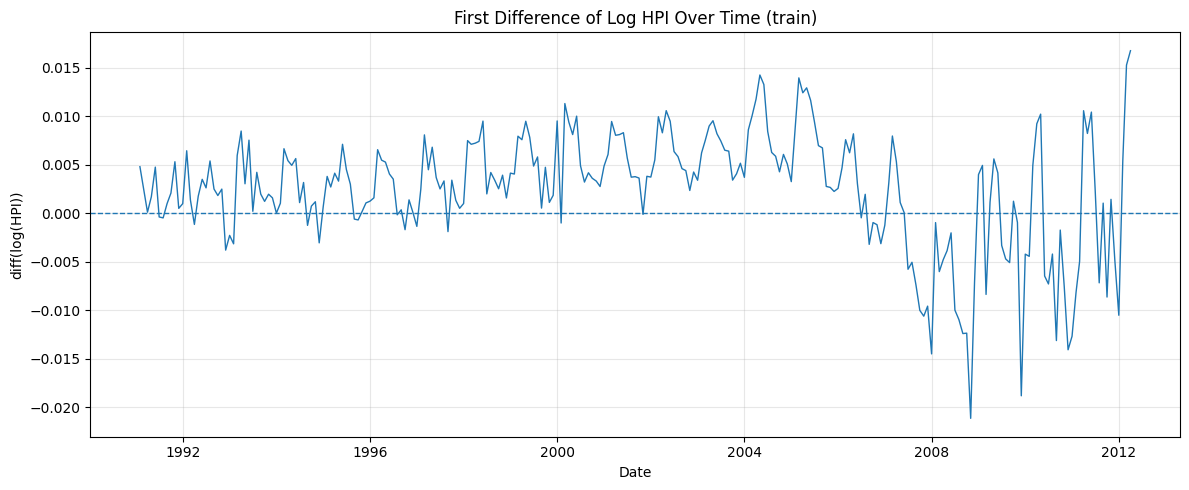

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(
    diff_log_train.index,
    diff_log_train["diff_log_hpi"],
    linewidth=1
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("First Difference of Log HPI Over Time (train)")
plt.xlabel("Date")
plt.ylabel("diff(log(HPI))")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

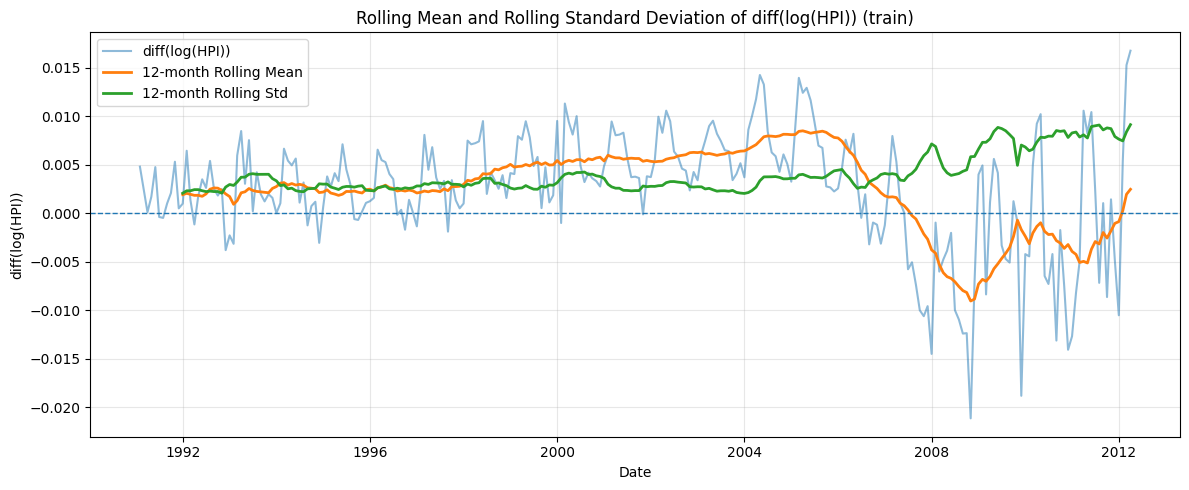

In [13]:
import matplotlib.dates as mdates

diff_log_train["rolling_mean_12"] = (
    diff_log_train["diff_log_hpi"]
    .rolling(window=12)
    .mean()
)

diff_log_train["rolling_std_12"] = (
    diff_log_train["diff_log_hpi"]
    .rolling(window=12)
    .std()
)

plt.figure(figsize=(12, 5))

plt.plot(
    diff_log_train.index,
    diff_log_train["diff_log_hpi"],
    label="diff(log(HPI))",
    alpha=0.5
)

plt.plot(
    diff_log_train.index,
    diff_log_train["rolling_mean_12"],
    label="12-month Rolling Mean",
    linewidth=2
)

plt.plot(
    diff_log_train.index,
    diff_log_train["rolling_std_12"],
    label="12-month Rolling Std",
    linewidth=2
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Rolling Mean and Rolling Standard Deviation of diff(log(HPI)) (train)")
plt.xlabel("Date")
plt.ylabel("diff(log(HPI))")
plt.legend()
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

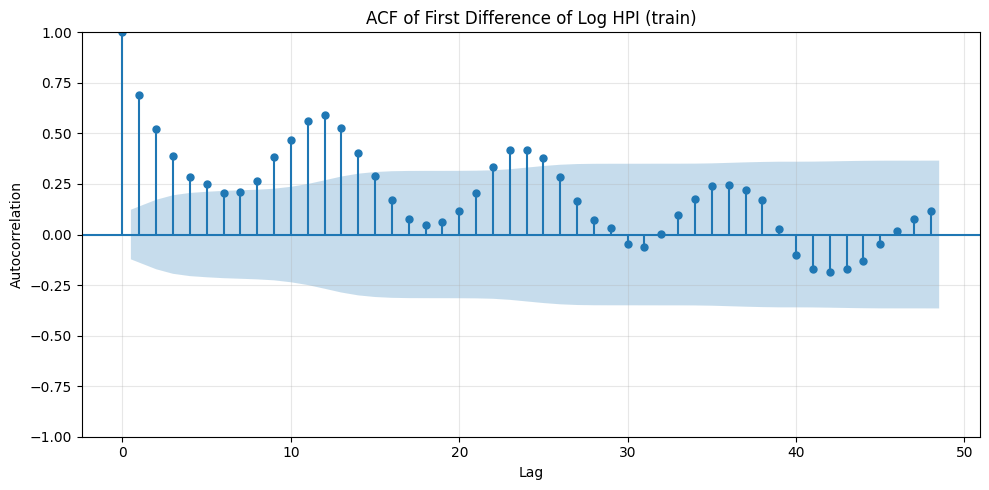

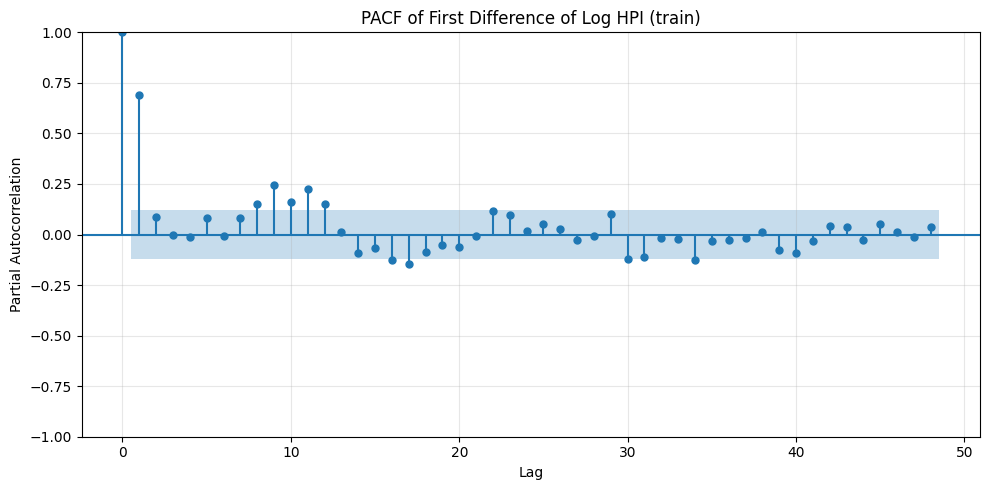

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_acf(
    diff_log_train["diff_log_hpi"],
    lags=48,
    ax=ax
)

ax.set_title("ACF of First Difference of Log HPI (train)")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(10, 5))

plot_pacf(
    diff_log_train["diff_log_hpi"],
    lags=48,
    ax=ax,
    method="ywm"
)

ax.set_title("PACF of First Difference of Log HPI (train)")
ax.set_xlabel("Lag")
ax.set_ylabel("Partial Autocorrelation")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
adf_result = adfuller(diff_log_train["diff_log_hpi"])

print("ADF Test for diff(log(HPI))")
print("--------------------------------")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"Number of Lags Used: {adf_result[2]}")
print(f"Number of Observations: {adf_result[3]}")

print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

ADF Test for diff(log(HPI))
--------------------------------
ADF Statistic: -2.4212
p-value: 0.1358
Number of Lags Used: 16
Number of Observations: 238
Critical Values:
   1%: -3.4581
   5%: -2.8738
   10%: -2.5733
